In [1]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Procesamiento de texto
from sklearn.feature_extraction.text import TfidfVectorizer

# Modelos
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [5]:
from google.colab import files
uploaded = files.upload()

Saving sms_spam_es_50.csv to sms_spam_es_50.csv


In [6]:
import pandas as pd

df = pd.read_csv("sms_spam_es_50.csv")
df.head()

,label,message
0,spam,Oferta exclusiva solo por hoy. Obtén 50% de de...
1,ham,"Feliz cumpleaños, que tengas un gran día."
2,ham,"Estoy en camino, llego en 10 minutos."
3,spam,Promoción válida hasta medianoche.
4,spam,Descuento especial solo para ti.


In [7]:
df["label"] = df["label"].map({"ham": 0, "spam": 1})

df.head()

,label,message
0,1,Oferta exclusiva solo por hoy. Obtén 50% de de...
1,0,"Feliz cumpleaños, que tengas un gran día."
2,0,"Estoy en camino, llego en 10 minutos."
3,1,Promoción válida hasta medianoche.
4,1,Descuento especial solo para ti.


In [8]:
X = df["message"]
y = df["label"]

print("Total registros:", X.shape[0])

Total registros: 50


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Entrenamiento:", X_train.shape[0])
print("Prueba:", X_test.shape[0])

Entrenamiento: 40
Prueba: 10


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Dimensión matriz:", X_train_tfidf.shape)

Dimensión matriz: (40, 323)


In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nReporte:")
print(classification_report(y_test, y_pred_nb))

Accuracy: 1.0

Reporte:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nReporte:")
print(classification_report(y_test, y_pred_lr))

Accuracy: 1.0

Reporte:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [13]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Naive Bayes Accuracy: 1.0
Logistic Regression Accuracy: 1.0


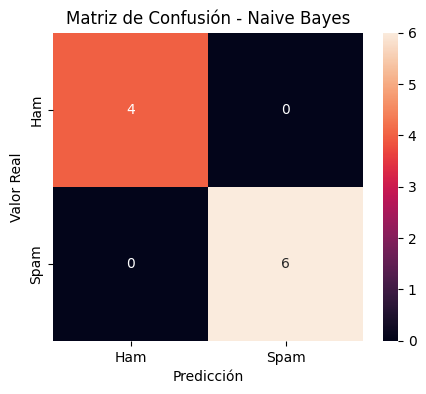

In [19]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Matriz de Confusión - Naive Bayes")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

In [15]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(nb_model, X_train_tfidf, y_train, cv=5)

print("Cross Validation Scores:", scores)
print("Promedio CV:", scores.mean())

Cross Validation Scores: [0.625 0.875 0.875 0.875 0.75 ]
Promedio CV: 0.8


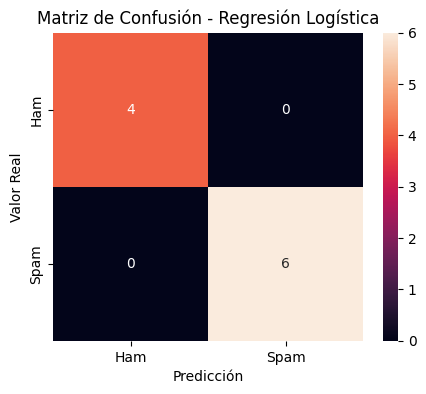

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

In [21]:
print("Naive Bayes")
print(confusion_matrix(y_test, y_pred_nb))

print("\nRegresión Logística")
print(confusion_matrix(y_test, y_pred_lr))

Naive Bayes
[[4 0]
 [0 6]]

Regresión Logística
[[4 0]
 [0 6]]
